In [1]:
import numpy as np
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_rotate_45_augmented_flip_horizontal_img153_jpg.rf.d6c9a2cfc14449739cfa3c7dc44ca885.jpg
/kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_augmented_flip_horizontal_img360_jpg.rf.1174acba2e2bfffbbfa4c1cd63009ba3.jpg
/kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_augmented_flip_horizontal_img476.jpg
/kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_img819_jpg.rf.a56ae5f661f572775d4e3ec9859633a6.jpg
/kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_flip_hor

Imports & Installs

In [2]:
!pip install torch torchvision

import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models

from torch.utils.data import Dataset, DataLoader


from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder

Datapath

In [3]:
DATASET_ROOT = "/kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split"

TRAIN_PATH = DATASET_ROOT + "/train"
VAL_PATH   = DATASET_ROOT + "/valid"
TEST_PATH  = DATASET_ROOT + "/test"

print(os.listdir(TRAIN_PATH))

['Second Degree Burn Partial of Intermediate Thickness', 'Third Degree Burn Full hickness', 'First Degree Burn Superficial Thickness', 'No Sunburn']


In [4]:
print(os.listdir(TRAIN_PATH))

['Second Degree Burn Partial of Intermediate Thickness', 'Third Degree Burn Full hickness', 'First Degree Burn Superficial Thickness', 'No Sunburn']


In [5]:
import os

print(os.listdir("/kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split"))

['valid', 'test', 'train']


Random image 

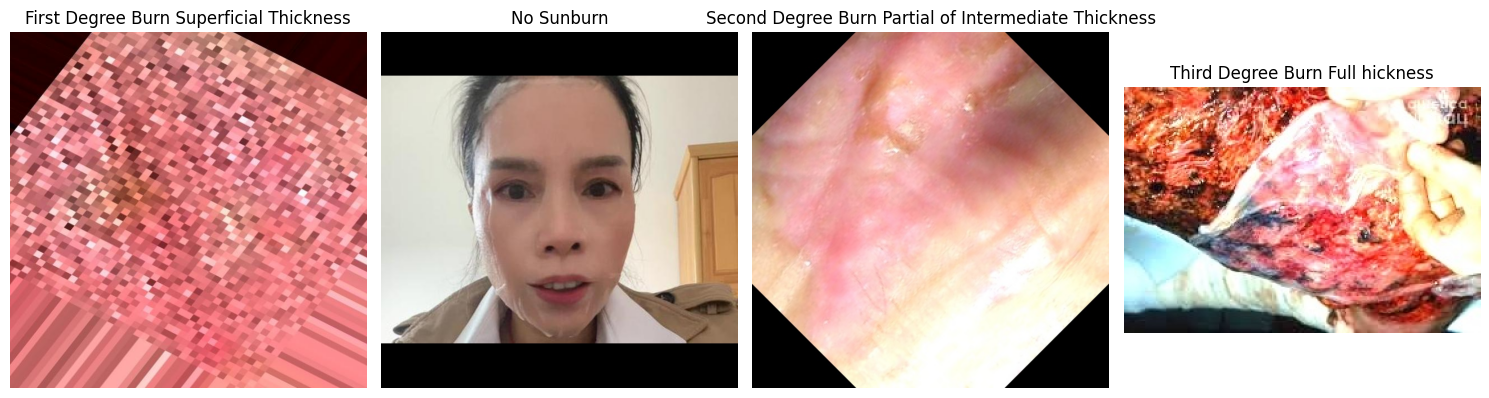

In [6]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def show_one_image_per_class(train_path):
    class_names = sorted(os.listdir(train_path))

    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(class_names):
        class_folder = os.path.join(train_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        images = []
        for file in os.listdir(class_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(class_folder, file))

        if len(images) == 0:
            continue

        img_path = random.choice(images)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(TRAIN_PATH)

Resize image

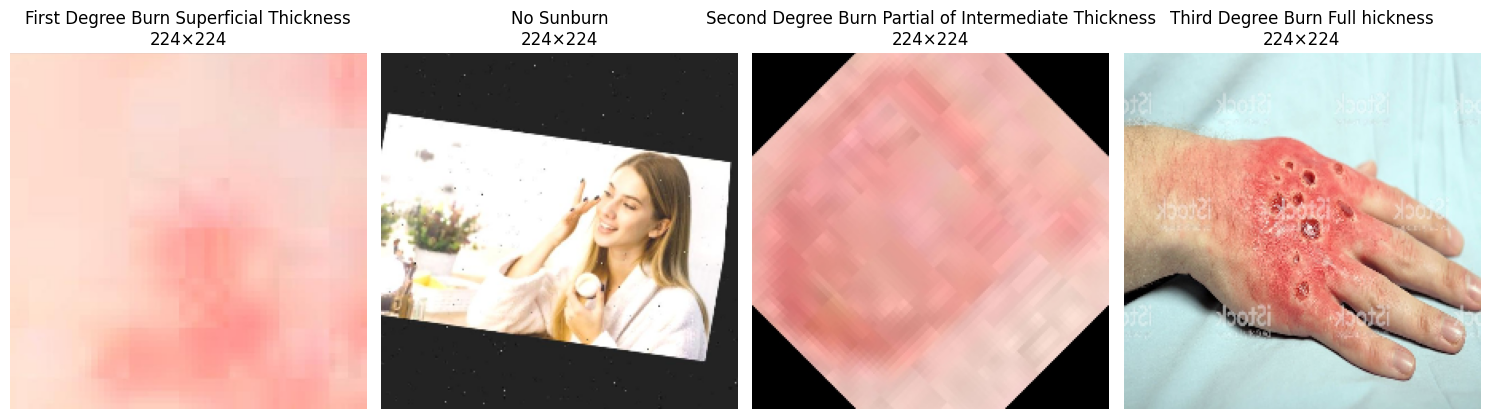

In [7]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def show_one_image_per_class(train_path):
    class_names = sorted(os.listdir(train_path))

    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(class_names):
        class_folder = os.path.join(train_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        images = []
        for file in os.listdir(class_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(class_folder, file))

        if len(images) == 0:
            continue

        img_path = random.choice(images)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ✅ RESIZE TO 224x224
        img = cv2.resize(img, (224, 224))

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
        plt.title(f"{class_name}\n224×224")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(TRAIN_PATH)

Skin Segmentation

Total images: 10817


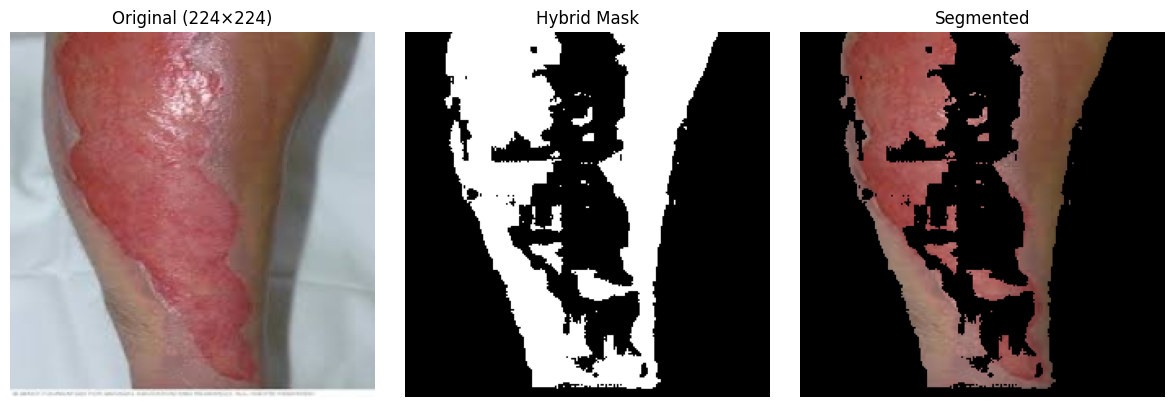

In [8]:
def hybrid_skin_mask(image):
    img = image.astype(np.float32)

    # RGB
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

    rgb_mask = (
        (R > 95) &
        (G > 40) &
        (B > 20) &
        ((np.max(img, axis=2) - np.min(img, axis=2)) > 15) &
        (np.abs(R - G) > 15) &
        (R > G) &
        (R > B)
    )

    rgb_mask = rgb_mask.astype(np.uint8)

    # HSV
    hsv = cv2.cvtColor(image.astype(np.uint8), cv2.COLOR_RGB2HSV)
    H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

    hsv_mask = (
        (H >= 0) & (H <= 50) &
        (S >= 0.23 * 255) & (S <= 0.68 * 255) &
        (V >= 0.35 * 255)
    )

    hsv_mask = hsv_mask.astype(np.uint8)

    # Combine
    final_mask = cv2.bitwise_and(rgb_mask, hsv_mask)

    return final_mask * 255

# Run ONCE
ALL_IMAGES = []

for root, _, files in os.walk(TRAIN_PATH):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            ALL_IMAGES.append(os.path.join(root, file))

print("Total images:", len(ALL_IMAGES))


def get_random_image_fast():
    return random.choice(ALL_IMAGES)

def show_hybrid_segmentation(image_path):
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    img = cv2.resize(img, (224, 224))   # faster first
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = hybrid_skin_mask(img)
    segmented = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Hybrid Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Segmented")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

img_path = get_random_image_fast()
show_hybrid_segmentation(img_path)

Burn Segmentation

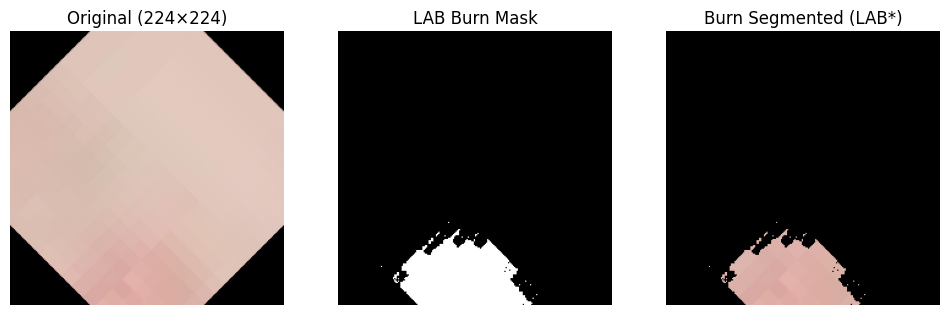

In [9]:
import cv2
import numpy as np

def lab_burn_mask(image):
    # Convert RGB → LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0]
    A = lab[:, :, 1]
    B = lab[:, :, 2]

    # Normalize (optional but improves stability)
    L = L / 255.0
    A = A / 255.0
    B = B / 255.0

    # -----------------------------
    # BURN RULE (heuristic)
    # -----------------------------
    burn_mask = (
        (A > 0.55) &      # strong redness
        (L > 0.2) & (L < 0.85)  # avoid extreme dark/light regions
    )

    return (burn_mask.astype(np.uint8) * 255)

import os, random

def get_random_image(path):
    imgs = []
    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(('.jpg','.png','.jpeg')):
                imgs.append(os.path.join(root, f))
    return random.choice(imgs)

import matplotlib.pyplot as plt

def show_lab_burn_segmentation(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    mask = lab_burn_mask(img)

    segmented = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("LAB Burn Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Burn Segmented (LAB*)")
    plt.axis("off")

    plt.show()

img_path = get_random_image(TRAIN_PATH)
show_lab_burn_segmentation(img_path)

Final Segmentation

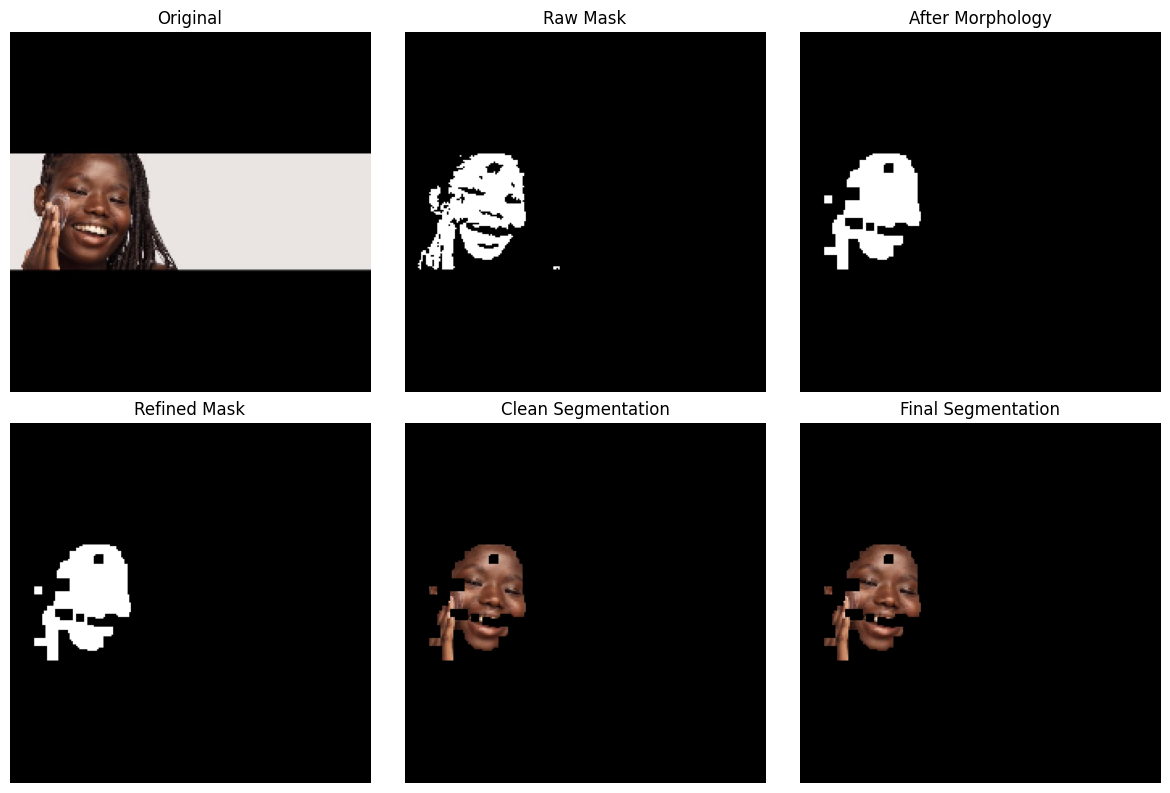

In [10]:
def get_random_image(path):
    imgs = []

    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                imgs.append(os.path.join(root, f))

    return random.choice(imgs)

def lab_burn_mask(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0] / 255.0
    A = lab[:, :, 1] / 255.0

    mask = (
        (A > 0.55) &
        (L > 0.2) & (L < 0.85)
    )

    return (mask.astype(np.uint8) * 255)

def post_process_mask(mask):
    kernel = np.ones((5,5), np.uint8)

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, 1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, 2)

    return closed

def refine_mask(mask):
    kernel = np.ones((3,3), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    return mask

def show_pipeline(train_path):

    img_path = get_random_image(train_path)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Step 1: LAB mask
    raw_mask = lab_burn_mask(img)

    # Step 2: Morphology
    clean_mask = post_process_mask(raw_mask)

    # Step 3: Refinement
    refined_mask = refine_mask(clean_mask)

    # Step 4: Segmentation
    raw_seg = cv2.bitwise_and(img, img, mask=raw_mask)
    clean_seg = cv2.bitwise_and(img, img, mask=clean_mask)
    final_seg = cv2.bitwise_and(img, img, mask=refined_mask)

    # Step 5: Plot
    plt.figure(figsize=(12,8))

    plt.subplot(2,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.imshow(raw_mask, cmap="gray")
    plt.title("Raw Mask")
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("After Morphology")
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.imshow(refined_mask, cmap="gray")
    plt.title("Refined Mask")
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.imshow(clean_seg)
    plt.title("Clean Segmentation")
    plt.axis("off")

    plt.subplot(2,3,6)
    plt.imshow(final_seg)
    plt.title("Final Segmentation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_pipeline(TRAIN_PATH)

Extracted region

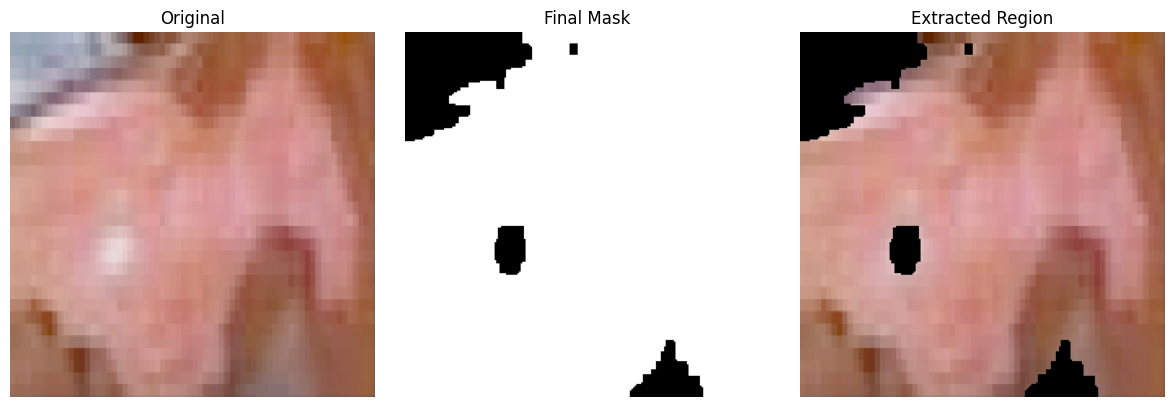

In [11]:
def extract_region(image, mask):
    # ensure mask is binary
    mask = (mask > 0).astype(np.uint8) * 255

    # extract region
    extracted = cv2.bitwise_and(image, image, mask=mask)

    return extracted

def show_region_extraction(train_path):
    img_path = get_random_image(train_path)

    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Step 1: LAB mask
    raw_mask = lab_burn_mask(img)

    # Step 2: Morphology
    clean_mask = post_process_mask(raw_mask)

    # Step 3: Region extraction
    extracted = extract_region(img, clean_mask)

    # Plot
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("Final Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(extracted)
    plt.title("Extracted Region")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
show_region_extraction(TRAIN_PATH)


3-channel region

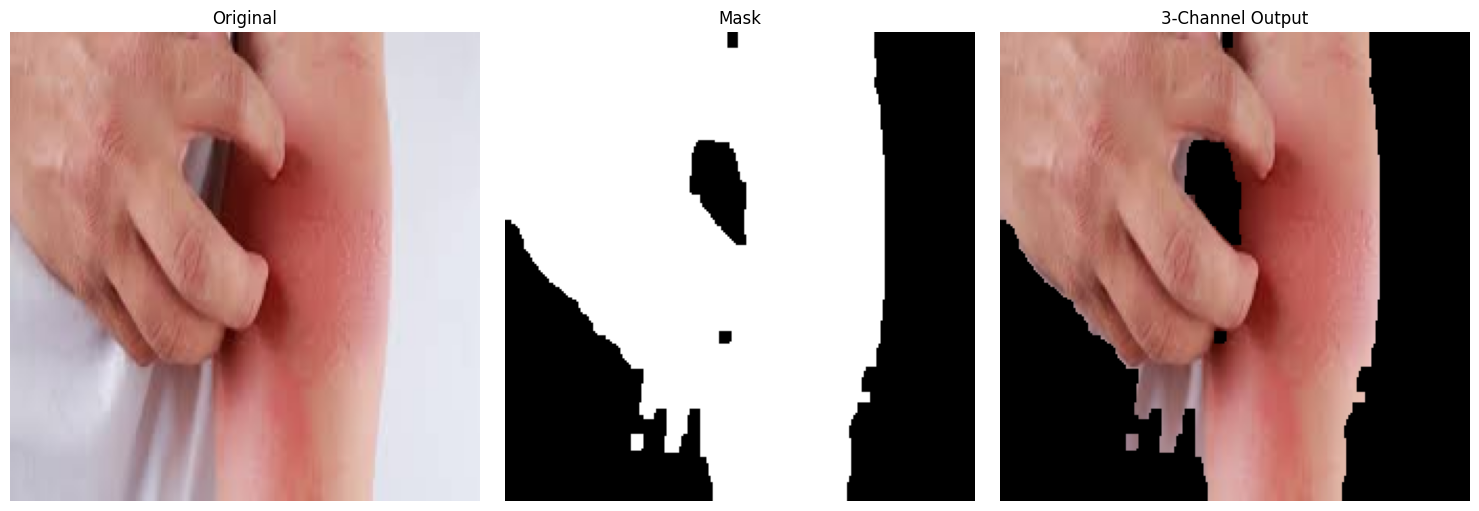

In [12]:
import cv2
import numpy as np

def extract_3channel_region(image, mask):
    # ensure binary mask
    mask = (mask > 0).astype(np.uint8)

    # expand mask to 3 channels
    mask_3ch = np.stack([mask, mask, mask], axis=-1)

    # apply mask
    output = image * mask_3ch

    return output

import matplotlib.pyplot as plt

def show_3channel_pipeline(train_path):
    img_path = get_random_image(train_path)

    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # LAB segmentation
    raw_mask = lab_burn_mask(img)

    # Morphology cleanup
    clean_mask = post_process_mask(raw_mask)

    # 3-channel output
    extracted_3ch = extract_3channel_region(img, clean_mask)

    # Visualization
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(extracted_3ch)
    plt.title("3-Channel Output")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_3channel_pipeline(TRAIN_PATH)

Model train

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [14]:
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3

DATA_DIR = "/kaggle/input/your-dataset"  # change this
MODEL_SAVE_PATH = "/kaggle/working/best_model.pth"

In [15]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [16]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=TRAIN_PATH,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=VAL_PATH,
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [17]:
model = models.alexnet(pretrained=True)

# Freeze convolution layers
for param in model.features.parameters():
    param.requires_grad = False

# Replace final classifier layer
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, len(train_dataset.classes))

model = model.to(device)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 210MB/s]


In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5
)

In [19]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs):

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader)
        train_acc = correct / total

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
        else:
            counter += 1

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print("-" * 40)

        # Early stopping
        if counter >= patience:
            print("Early stopping triggered")
            break

In [20]:
train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    EPOCHS
)

Epoch 1/100
Train Loss: 0.7971, Train Acc: 0.6488
Val Loss: 1.0294, Val Acc: 0.6015
----------------------------------------
Epoch 2/100
Train Loss: 0.6627, Train Acc: 0.7123
Val Loss: 0.7014, Val Acc: 0.6524
----------------------------------------
Epoch 3/100
Train Loss: 0.6145, Train Acc: 0.7424
Val Loss: 0.5834, Val Acc: 0.7388
----------------------------------------
Epoch 4/100
Train Loss: 0.5796, Train Acc: 0.7436
Val Loss: 0.5780, Val Acc: 0.7556
----------------------------------------
Epoch 5/100
Train Loss: 0.5410, Train Acc: 0.7776
Val Loss: 0.5415, Val Acc: 0.7569
----------------------------------------
Epoch 6/100
Train Loss: 0.5311, Train Acc: 0.7792
Val Loss: 0.5074, Val Acc: 0.7876
----------------------------------------
Epoch 7/100
Train Loss: 0.4954, Train Acc: 0.7930
Val Loss: 0.5731, Val Acc: 0.7617
----------------------------------------
Epoch 8/100
Train Loss: 0.4691, Train Acc: 0.8042
Val Loss: 0.5378, Val Acc: 0.7802
----------------------------------------


Accuracy

In [21]:
import time
import torch

DATASET_ROOT = "/kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split"
TEST_PATH = DATASET_ROOT + "/test"

from torchvision import datasets
from torch.utils.data import DataLoader

test_dataset = datasets.ImageFolder(
    root=TEST_PATH,
    transform=val_transforms  # same as validation
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

def evaluate(model, loader, device):
    model.eval()

    correct, total = 0, 0

    start_time = time.time()

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    end_time = time.time()

    accuracy = 100 * correct / total
    runtime = end_time - start_time

    return accuracy, runtime

In [22]:
train_acc, train_time = evaluate(model, train_loader, device)
val_acc, val_time = evaluate(model, val_loader, device)
test_acc, test_time = evaluate(model, test_loader, device)

print(f"Train Accuracy: {train_acc:.2f}% | Time: {train_time:.2f}s")
print(f"Val Accuracy:   {val_acc:.2f}% | Time: {val_time:.2f}s")
print(f"Test Accuracy:  {test_acc:.2f}% | Time: {test_time:.2f}s")

Train Accuracy: 92.77% | Time: 61.25s
Val Accuracy:   84.02% | Time: 12.63s
Test Accuracy:  83.68% | Time: 25.46s


Per-class accuracy

In [23]:
import numpy as np
import torch

def get_predictions(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(model, test_loader)
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(train_dataset.classes):
    print(f"{cls}: {per_class_acc[i]*100:.2f}%")



First Degree Burn Superficial Thickness: 64.11%
No Sunburn: 97.30%
Second Degree Burn Partial of Intermediate Thickness: 88.43%
Third Degree Burn Full hickness: 88.06%


Saved to: /kaggle/working/per_class_accuracy.png


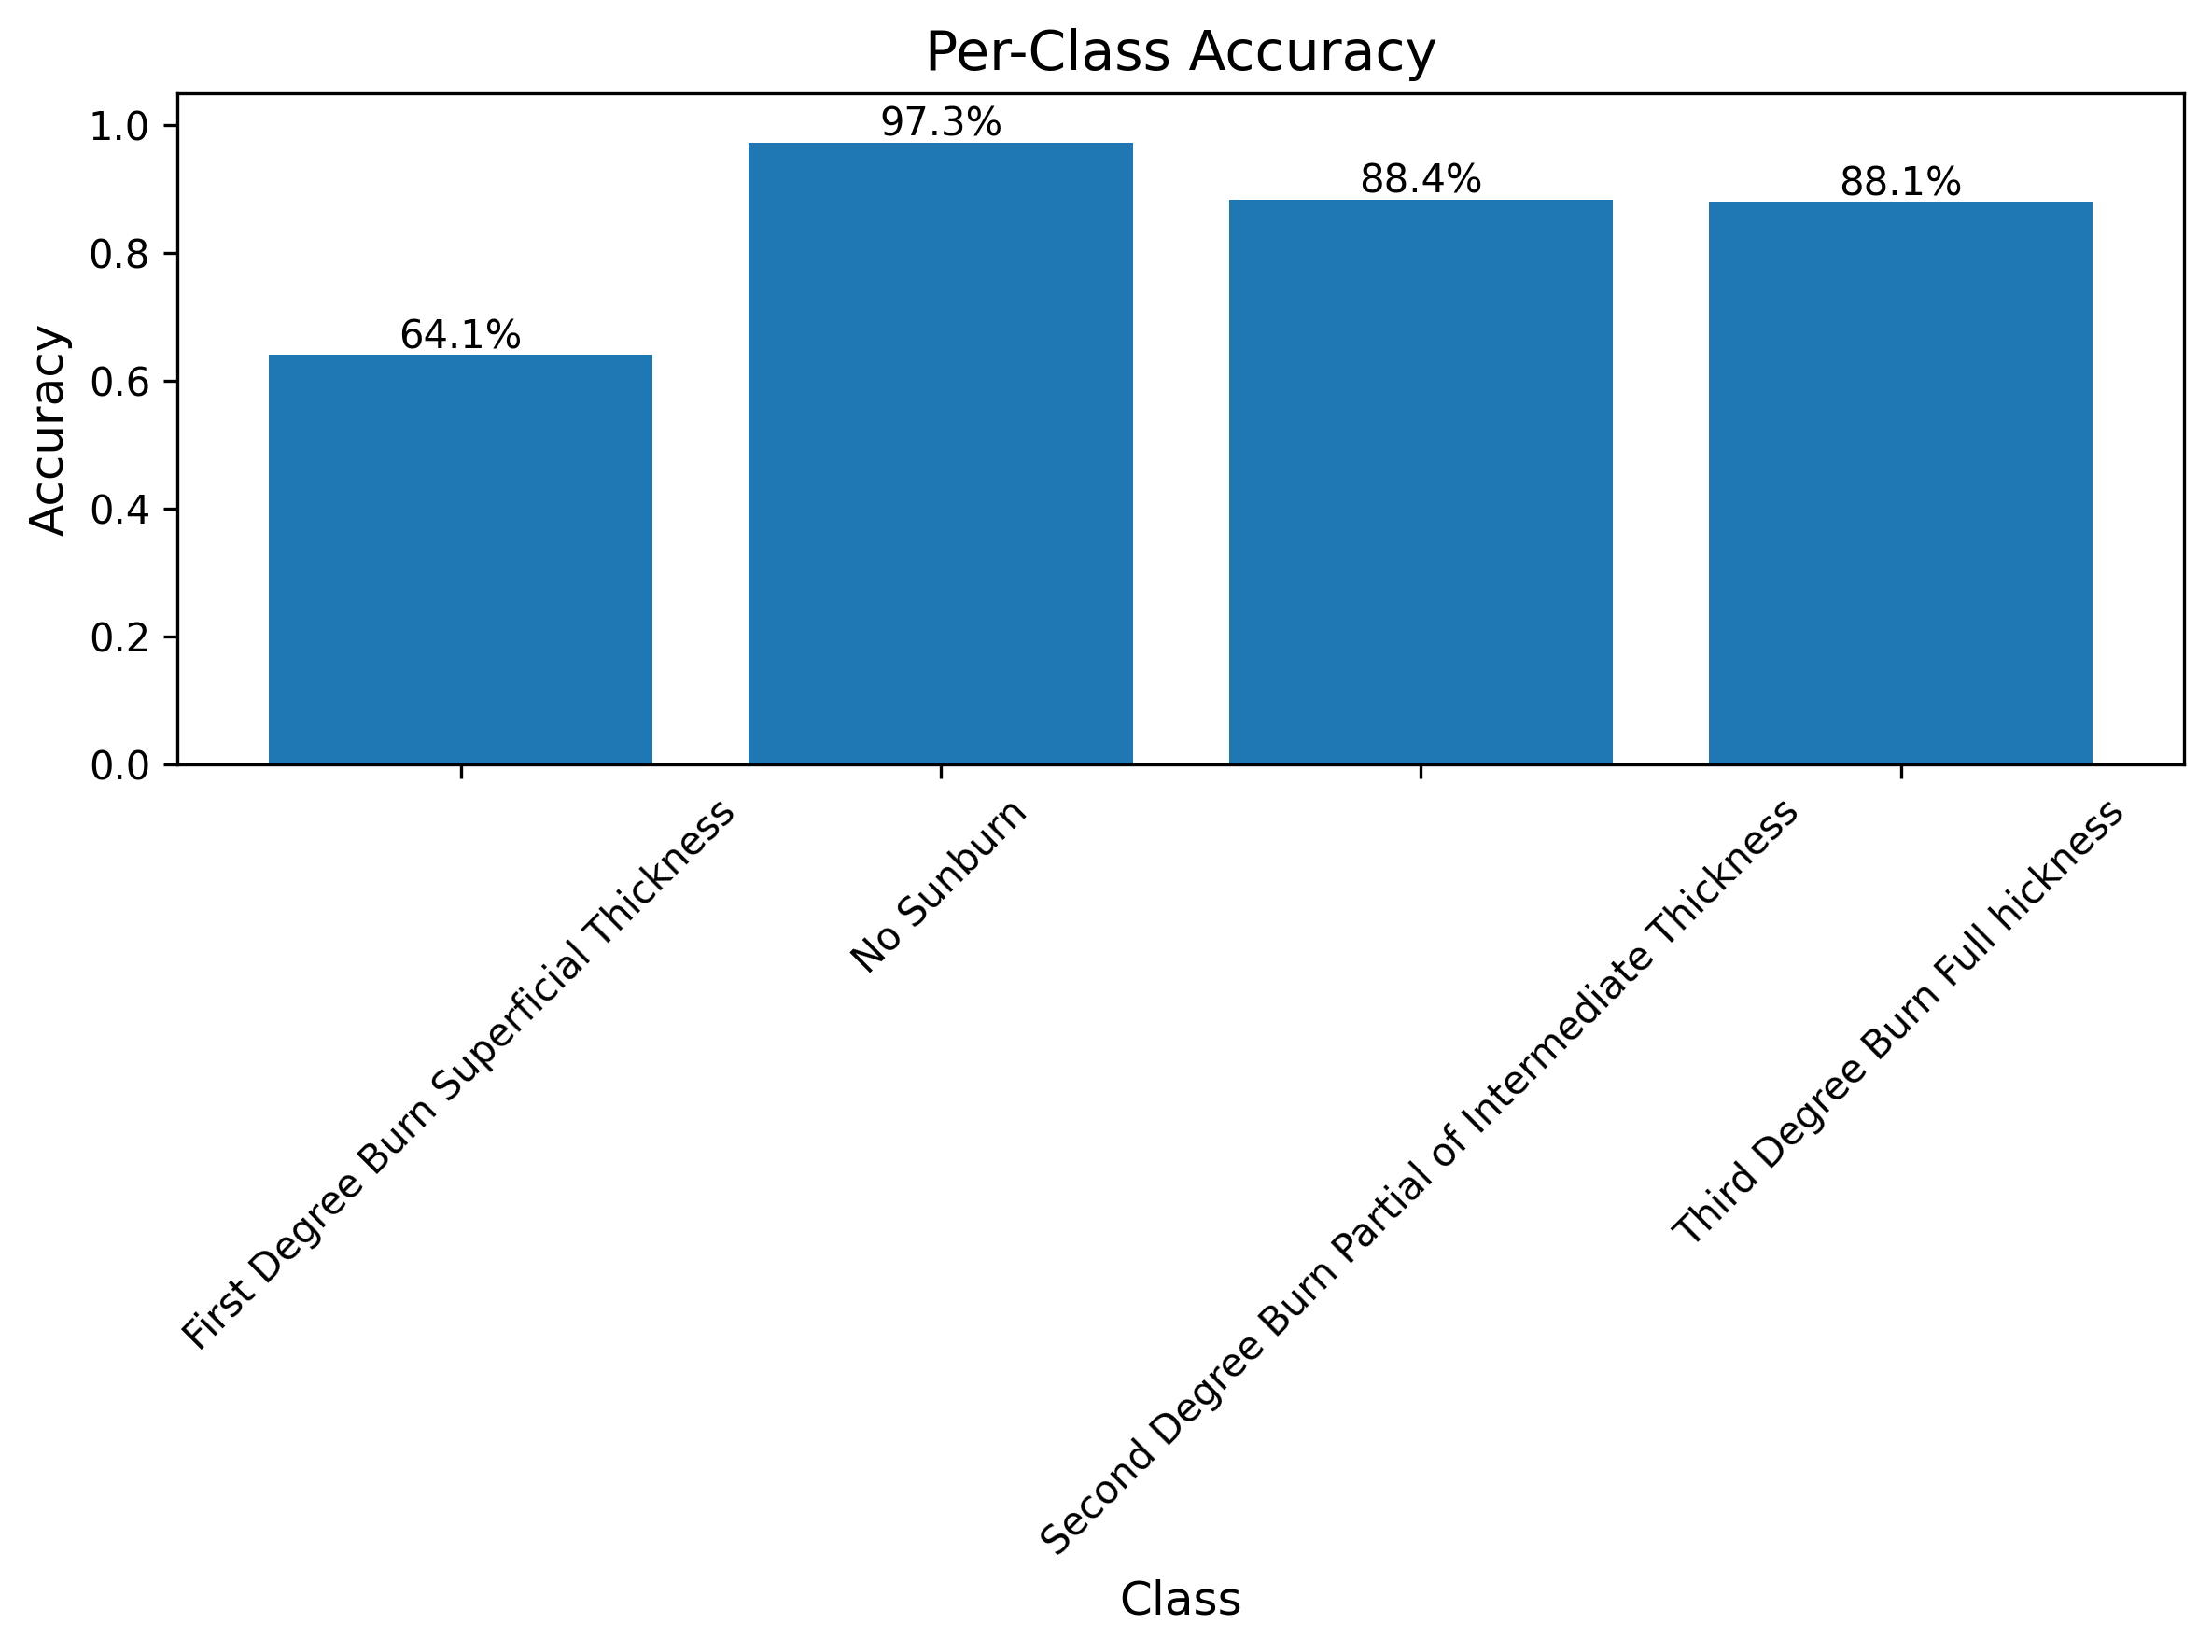

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_per_class_accuracy(
    y_true,
    y_pred,
    class_names,
    save_path="/kaggle/working/per_class_accuracy.png"
):

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # ✅ Per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    plt.figure(figsize=(8,6), dpi=300)

    # Bar plot
    x = np.arange(len(class_names))
    plt.bar(x, per_class_acc)

    plt.xticks(x, class_names, rotation=45, fontsize=10)
    plt.yticks(fontsize=10)

    plt.ylabel("Accuracy", fontsize=12)
    plt.xlabel("Class", fontsize=12)
    plt.title("Per-Class Accuracy", fontsize=14)

    # Add values on top
    for i, v in enumerate(per_class_acc):
        plt.text(i, v + 0.01, f"{v*100:.1f}%", ha='center', fontsize=10)

    plt.ylim(0, 1.05)

    plt.tight_layout()

    # ✅ Save high-resolution image
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved to: {save_path}")

    plt.show()

plot_per_class_accuracy(
    y_true,
    y_pred,
    train_dataset.classes
)

Confusion matrix & Normalised confusion matrix

In [25]:
def get_predictions(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(model, test_loader)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[318   2 165  11]
 [  0 144   3   1]
 [ 28   1 848  82]
 [  6   0  80 634]]


In [26]:
from sklearn.metrics import classification_report
import torch

def get_classification_metrics(model, loader, device, class_names):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))

In [27]:
class_names = train_dataset.classes

get_classification_metrics(model, test_loader, device, class_names)

                                                      precision    recall  f1-score   support

             First Degree Burn Superficial Thickness       0.90      0.64      0.75       496
                                          No Sunburn       0.98      0.97      0.98       148
Second Degree Burn Partial of Intermediate Thickness       0.77      0.88      0.83       959
                     Third Degree Burn Full hickness       0.87      0.88      0.88       720

                                            accuracy                           0.84      2323
                                           macro avg       0.88      0.84      0.86      2323
                                        weighted avg       0.84      0.84      0.83      2323



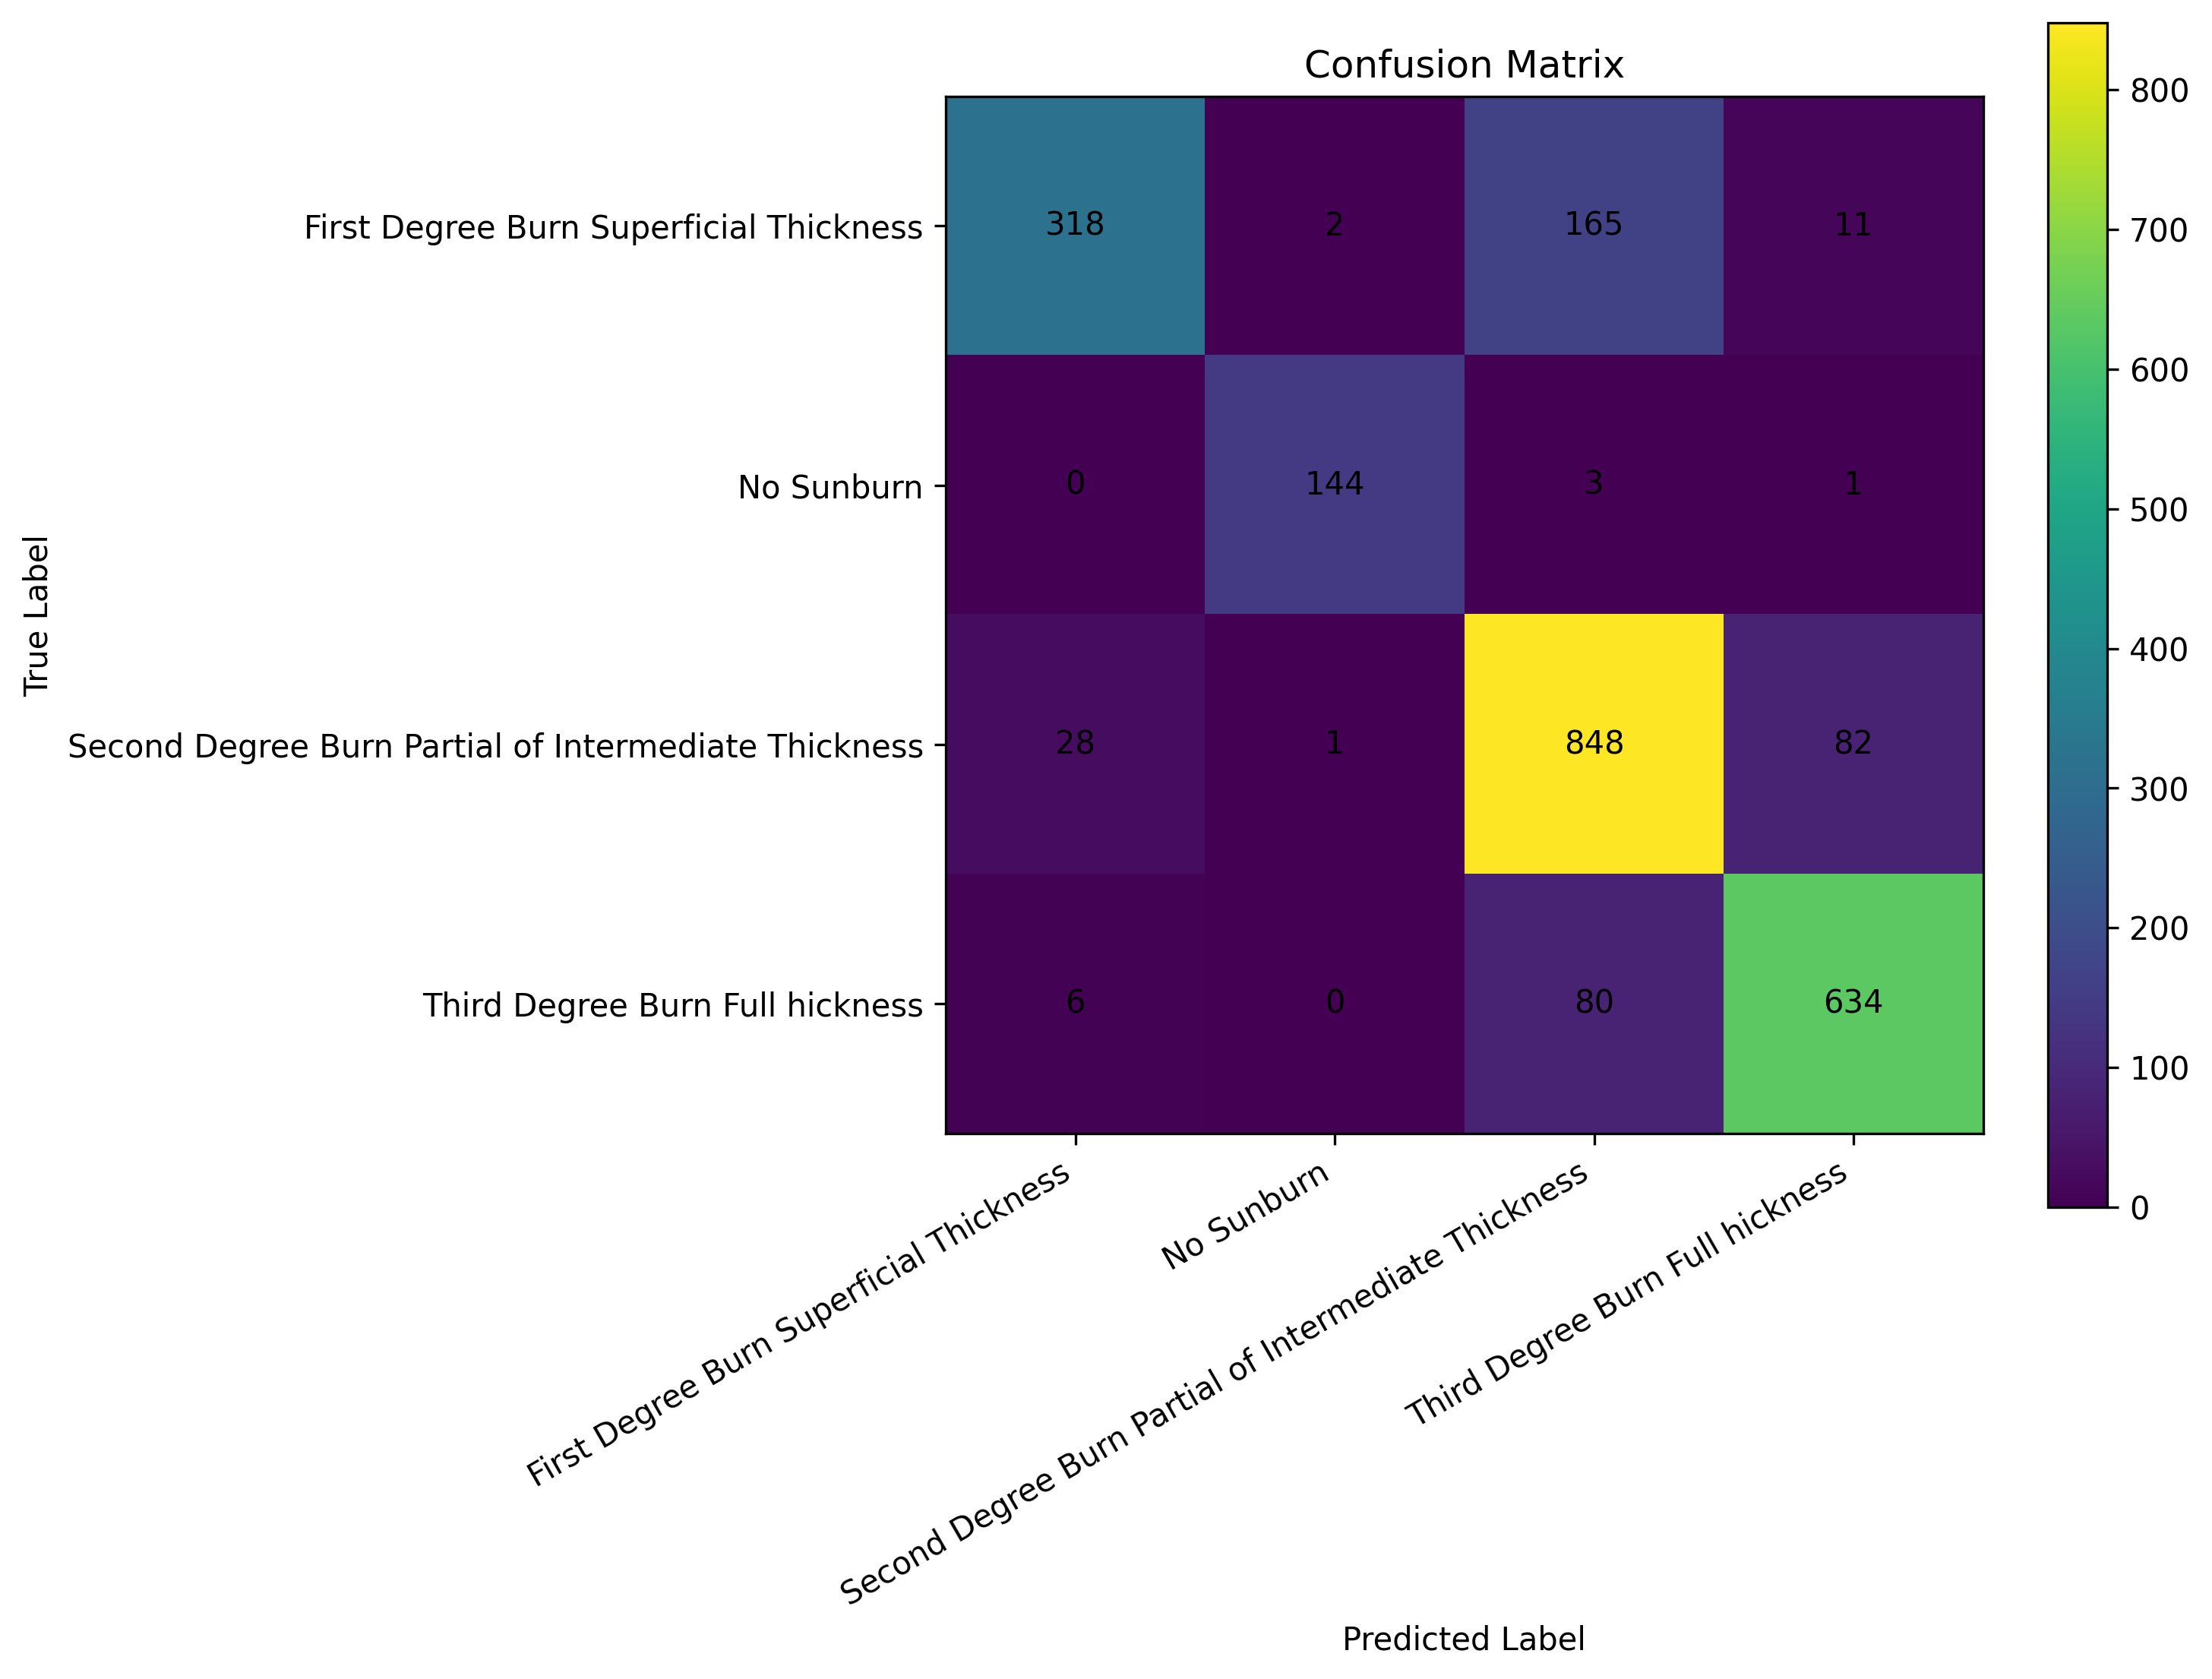

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

classes = train_dataset.classes
x = np.arange(len(classes))

plt.figure(figsize=(10,8), dpi=300)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

# ✅ Proper tick placement
plt.xticks(x, classes, rotation=30, ha='right')
plt.yticks(x, classes)

# ✅ Add spacing fix
plt.gca().set_xticks(x)
plt.gca().set_yticks(x)

# ✅ Add values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center", va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=300)
plt.show()

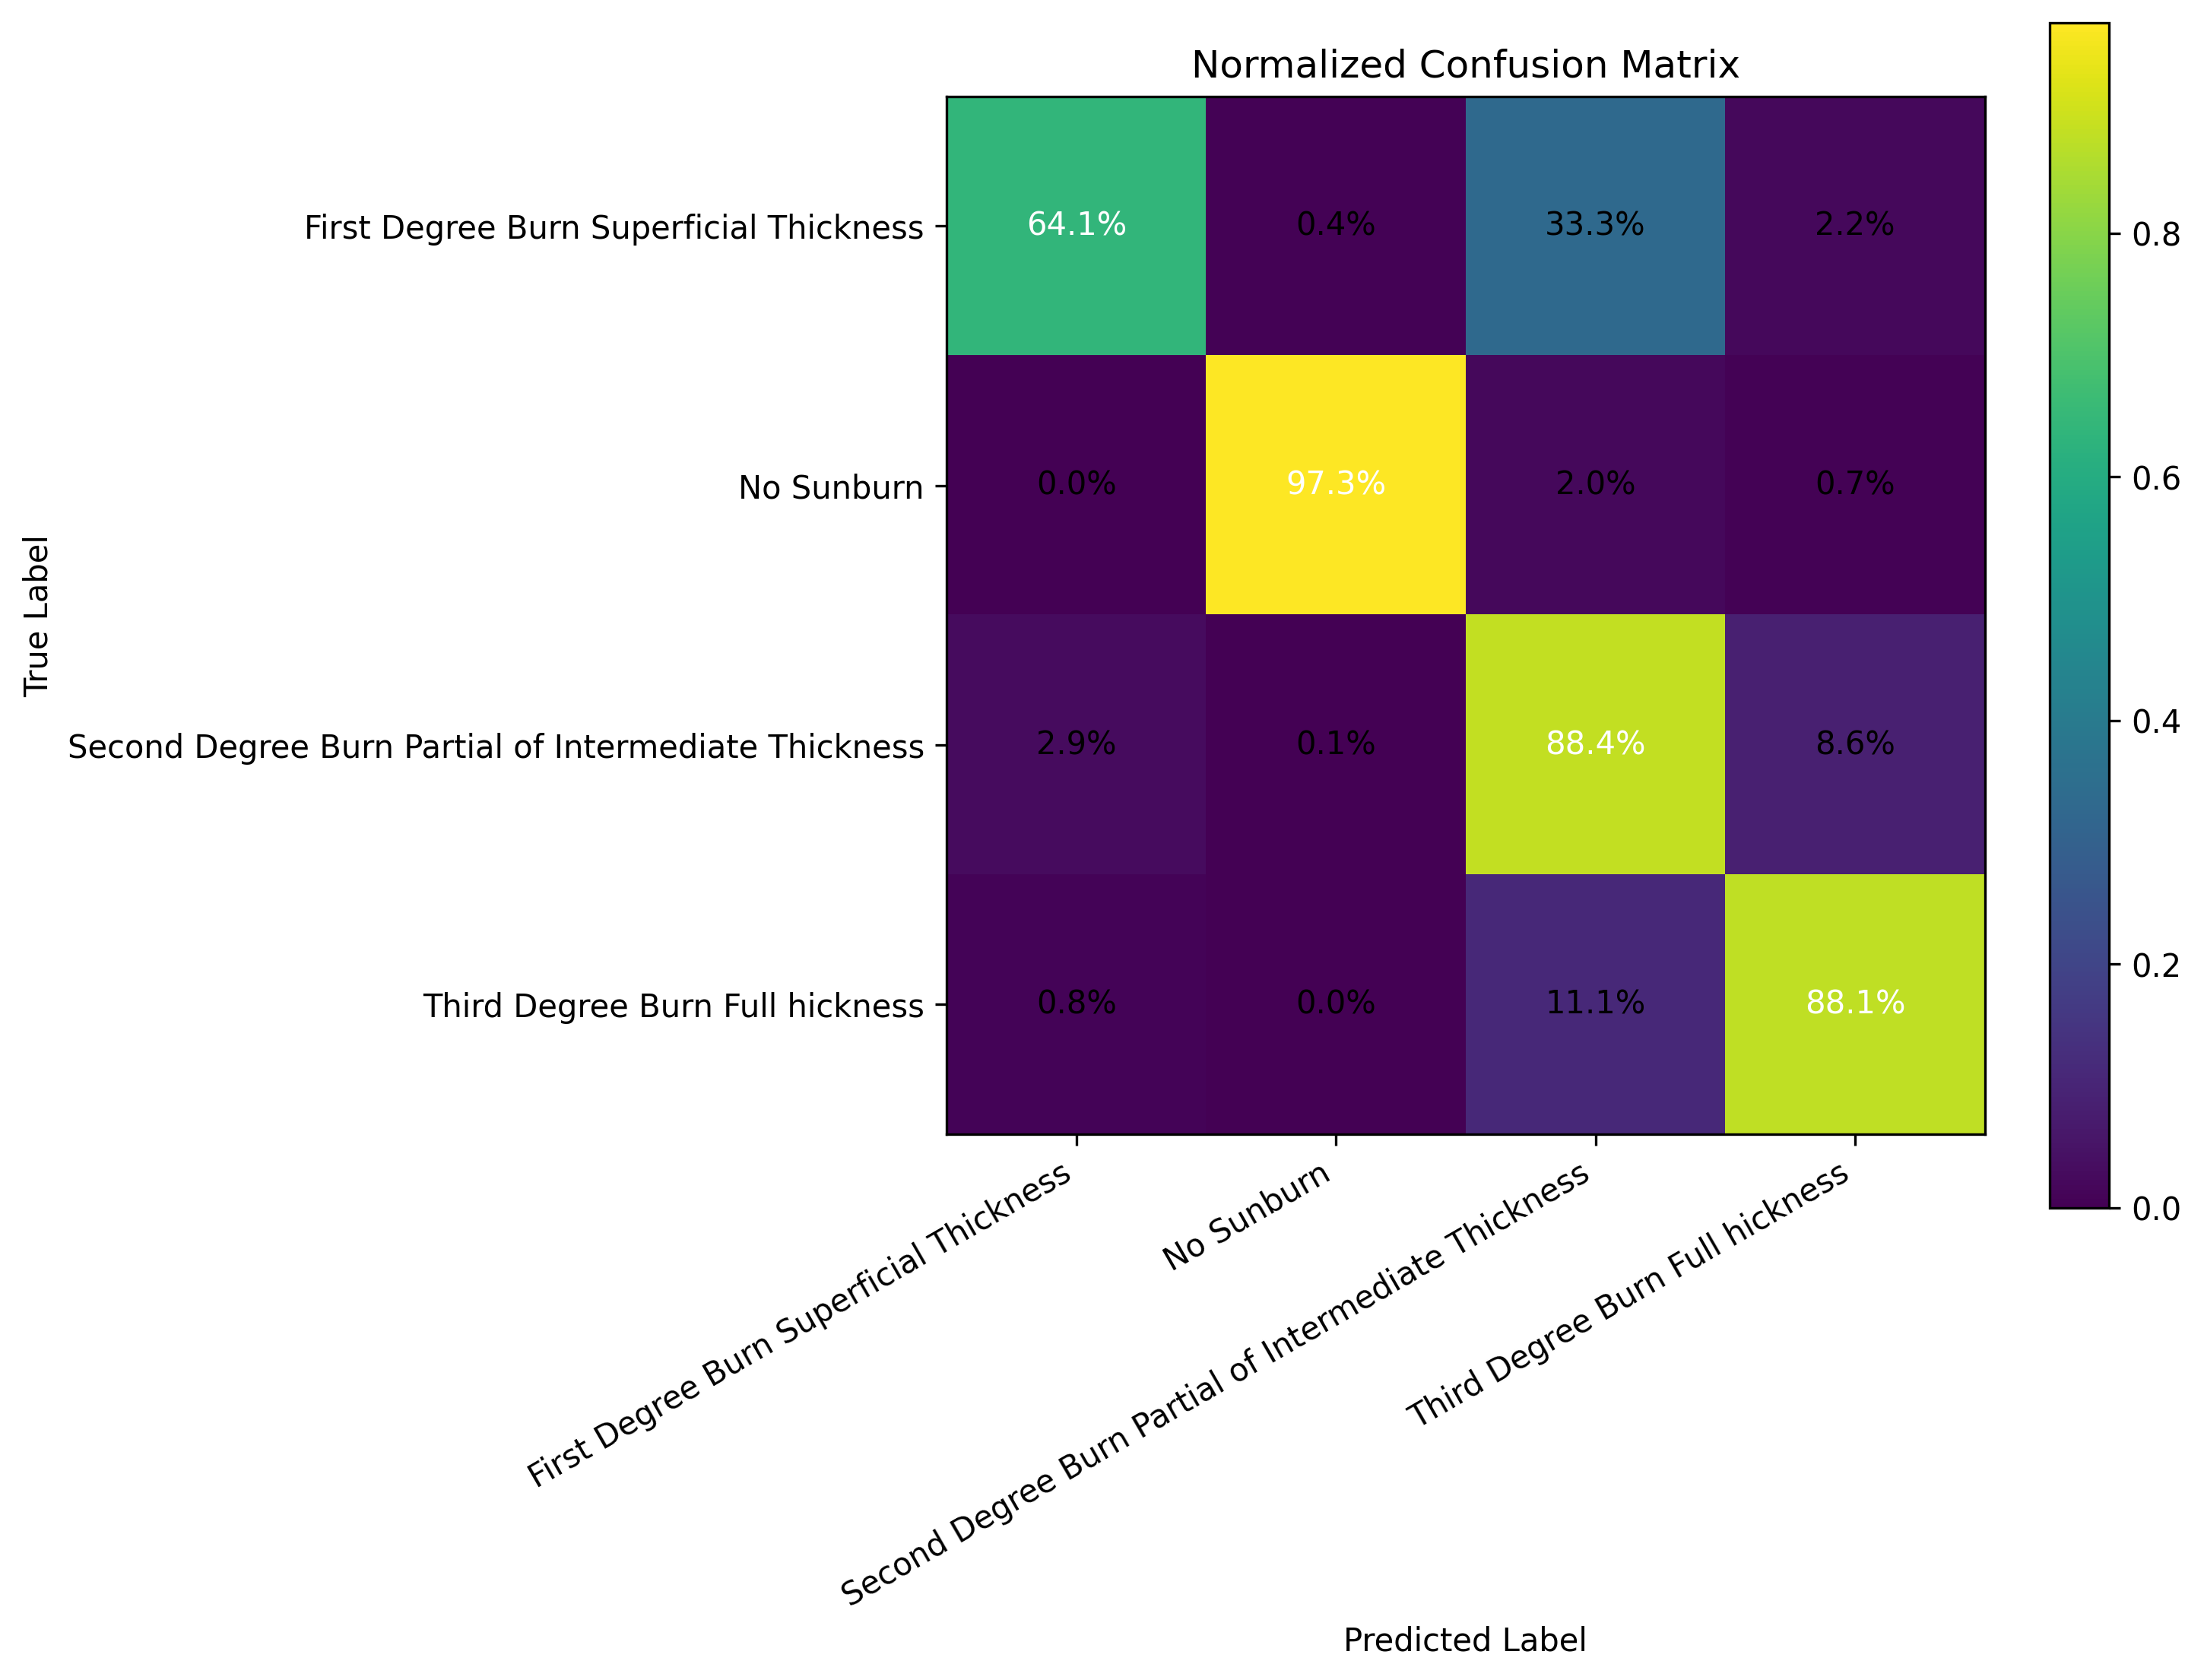

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize (row-wise)
cm_norm = np.divide(
    cm.astype(float),
    cm.sum(axis=1, keepdims=True),
    where=cm.sum(axis=1, keepdims=True) != 0
)

classes = train_dataset.classes
x = np.arange(len(classes))

plt.figure(figsize=(10,8), dpi=300)

# Plot normalized matrix
plt.imshow(cm_norm)
plt.title("Normalized Confusion Matrix")
plt.colorbar()

# Proper ticks
plt.xticks(x, classes, rotation=30, ha='right')
plt.yticks(x, classes)

# Add percentage values
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i, f"{cm_norm[i,j]*100:.1f}%",
            ha="center", va="center",
            color="white" if cm_norm[i,j] > 0.5 else "black"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("/kaggle/working/normalized_confusion_matrix.png", dpi=300)
plt.show()

Multiclass ROC curve

In [30]:
import torch
import numpy as np

def get_probs_and_labels(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_probs)

y_true, y_probs = get_probs_and_labels(model, test_loader)

Saved to: /kaggle/working/roc_curve.png


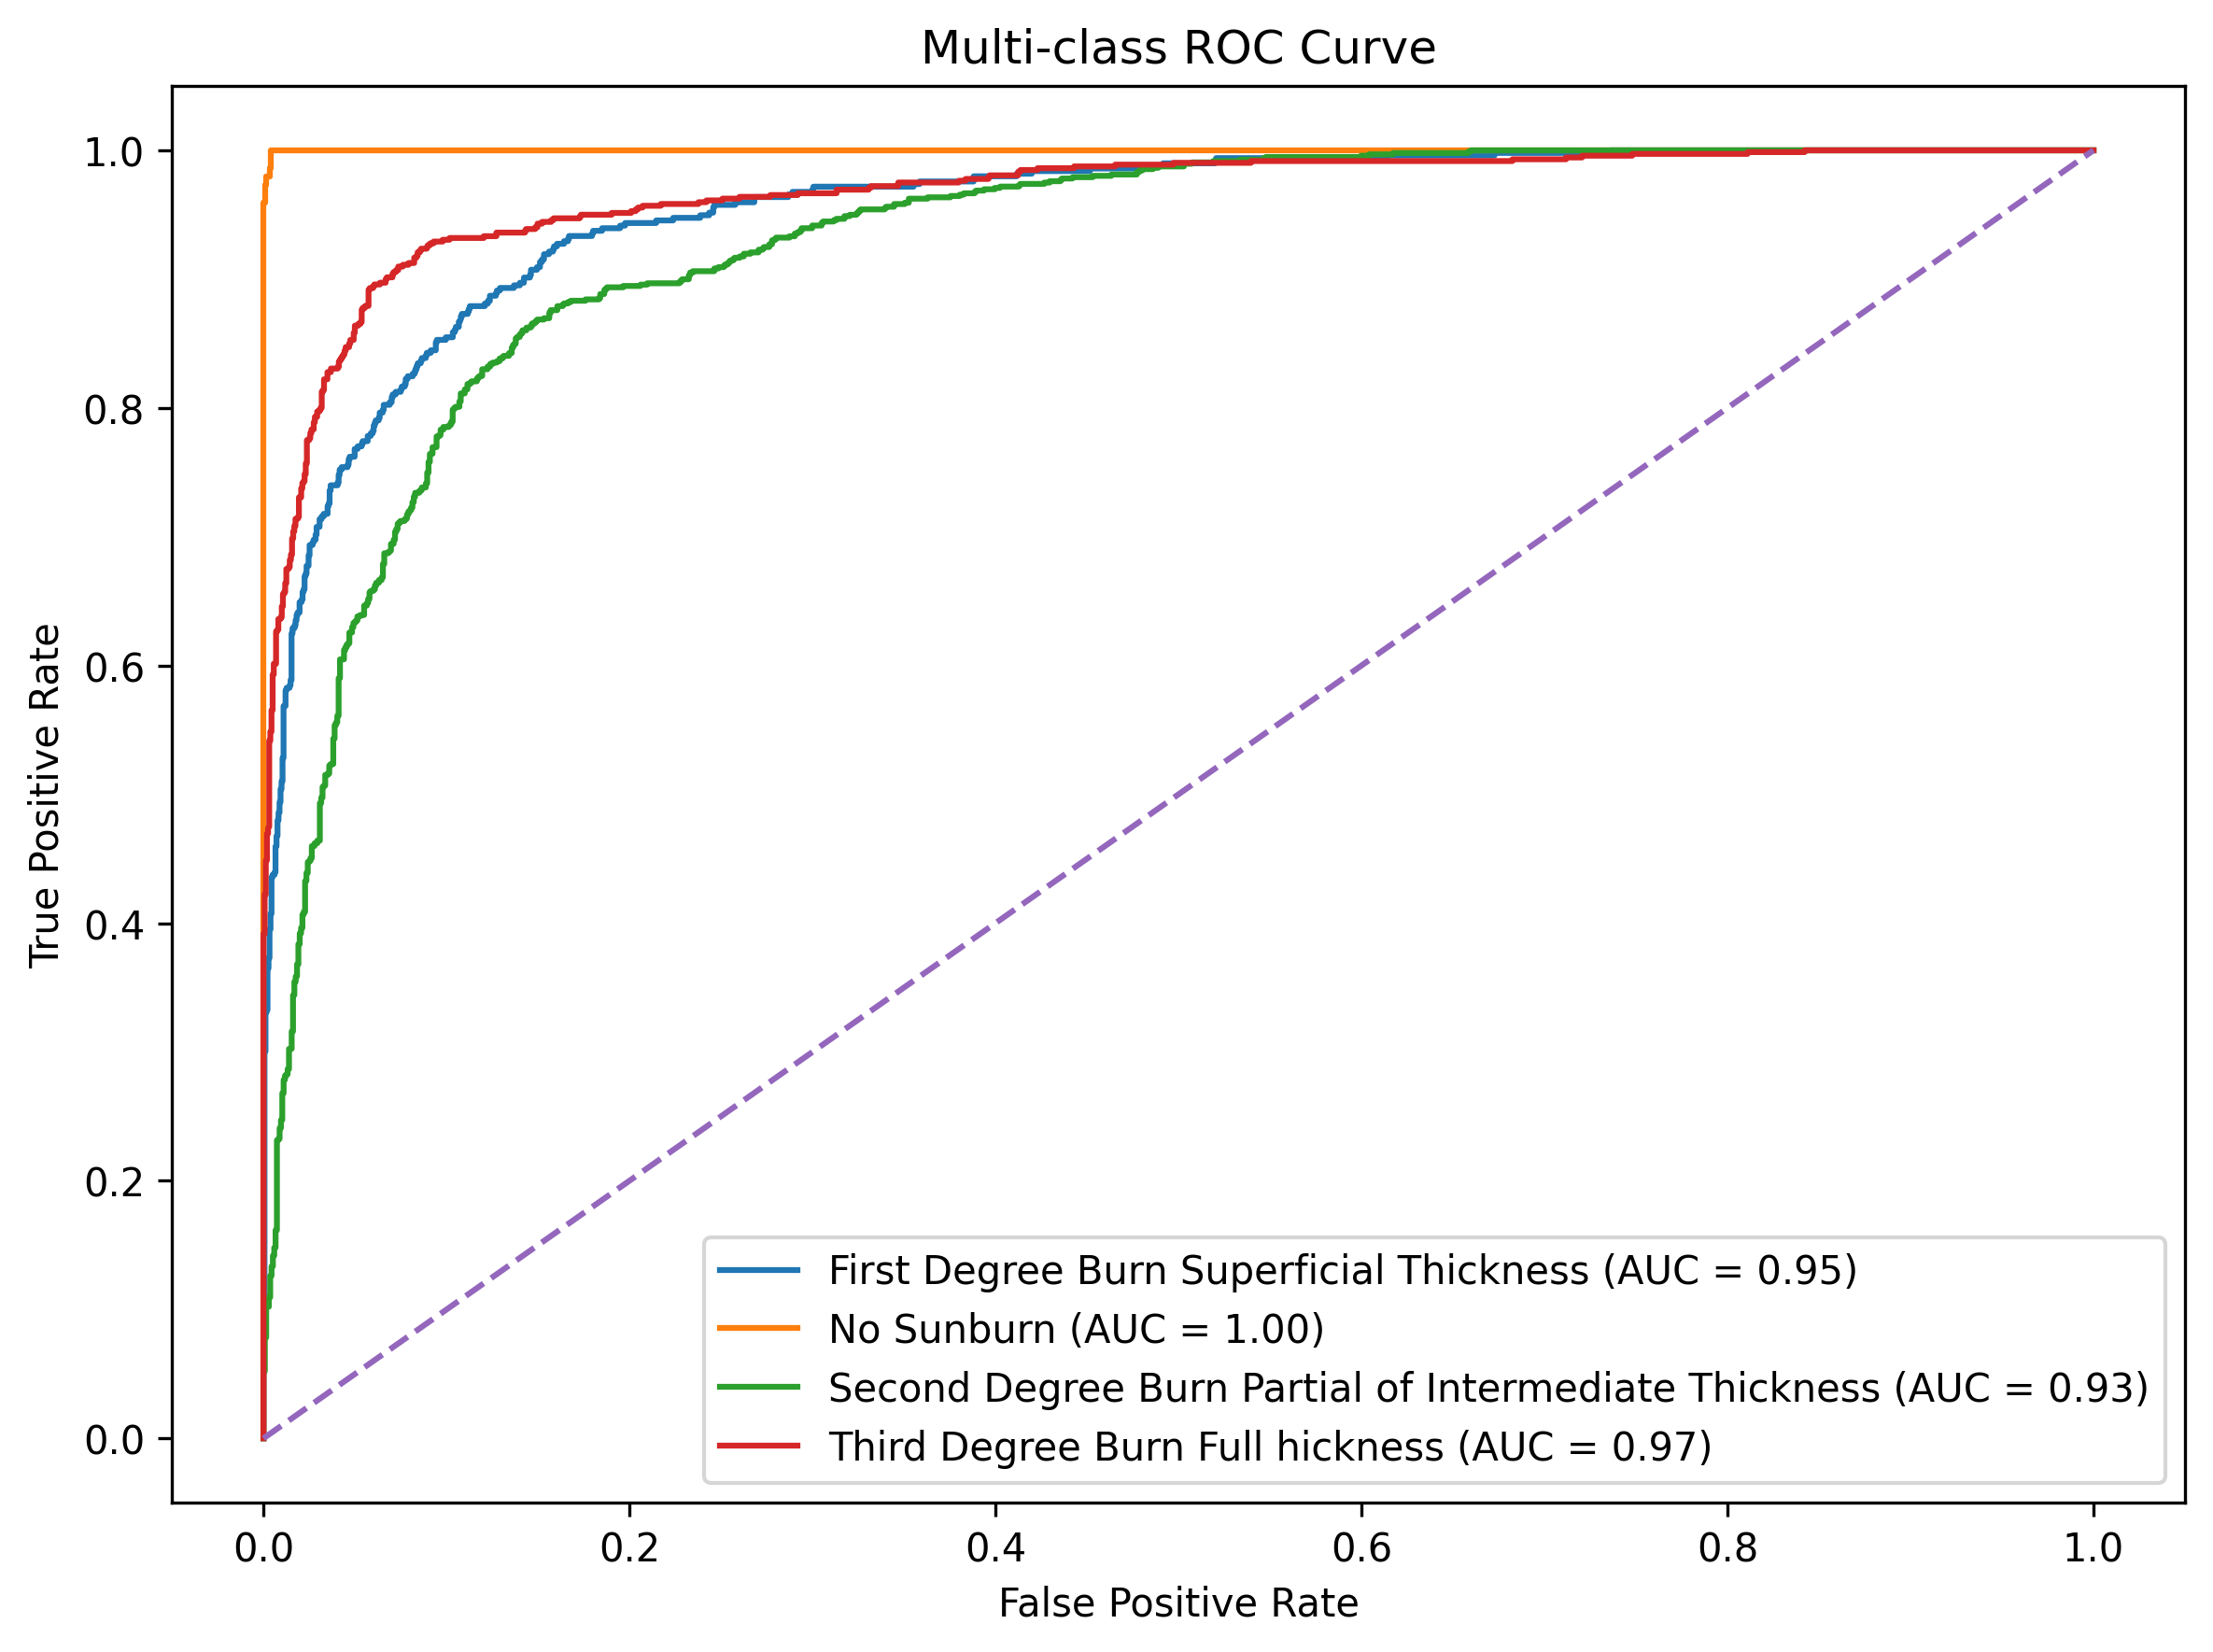

In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

def plot_multiclass_roc(y_true, y_probs, class_names,
                       save_path="/kaggle/working/roc_curve.png"):

    n_classes = len(class_names)

    # Binarize labels
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    plt.figure(figsize=(8,6), dpi=300)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

    # Diagonal line
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-class ROC Curve")
    plt.legend(loc="lower right")

    plt.tight_layout()

    # Save high-res PNG
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved to: {save_path}")

    plt.show()

plot_multiclass_roc(
    y_true,
    y_probs,
    train_dataset.classes
)

Micro-average ROC curve

Saved to: /kaggle/working/micro_roc.png


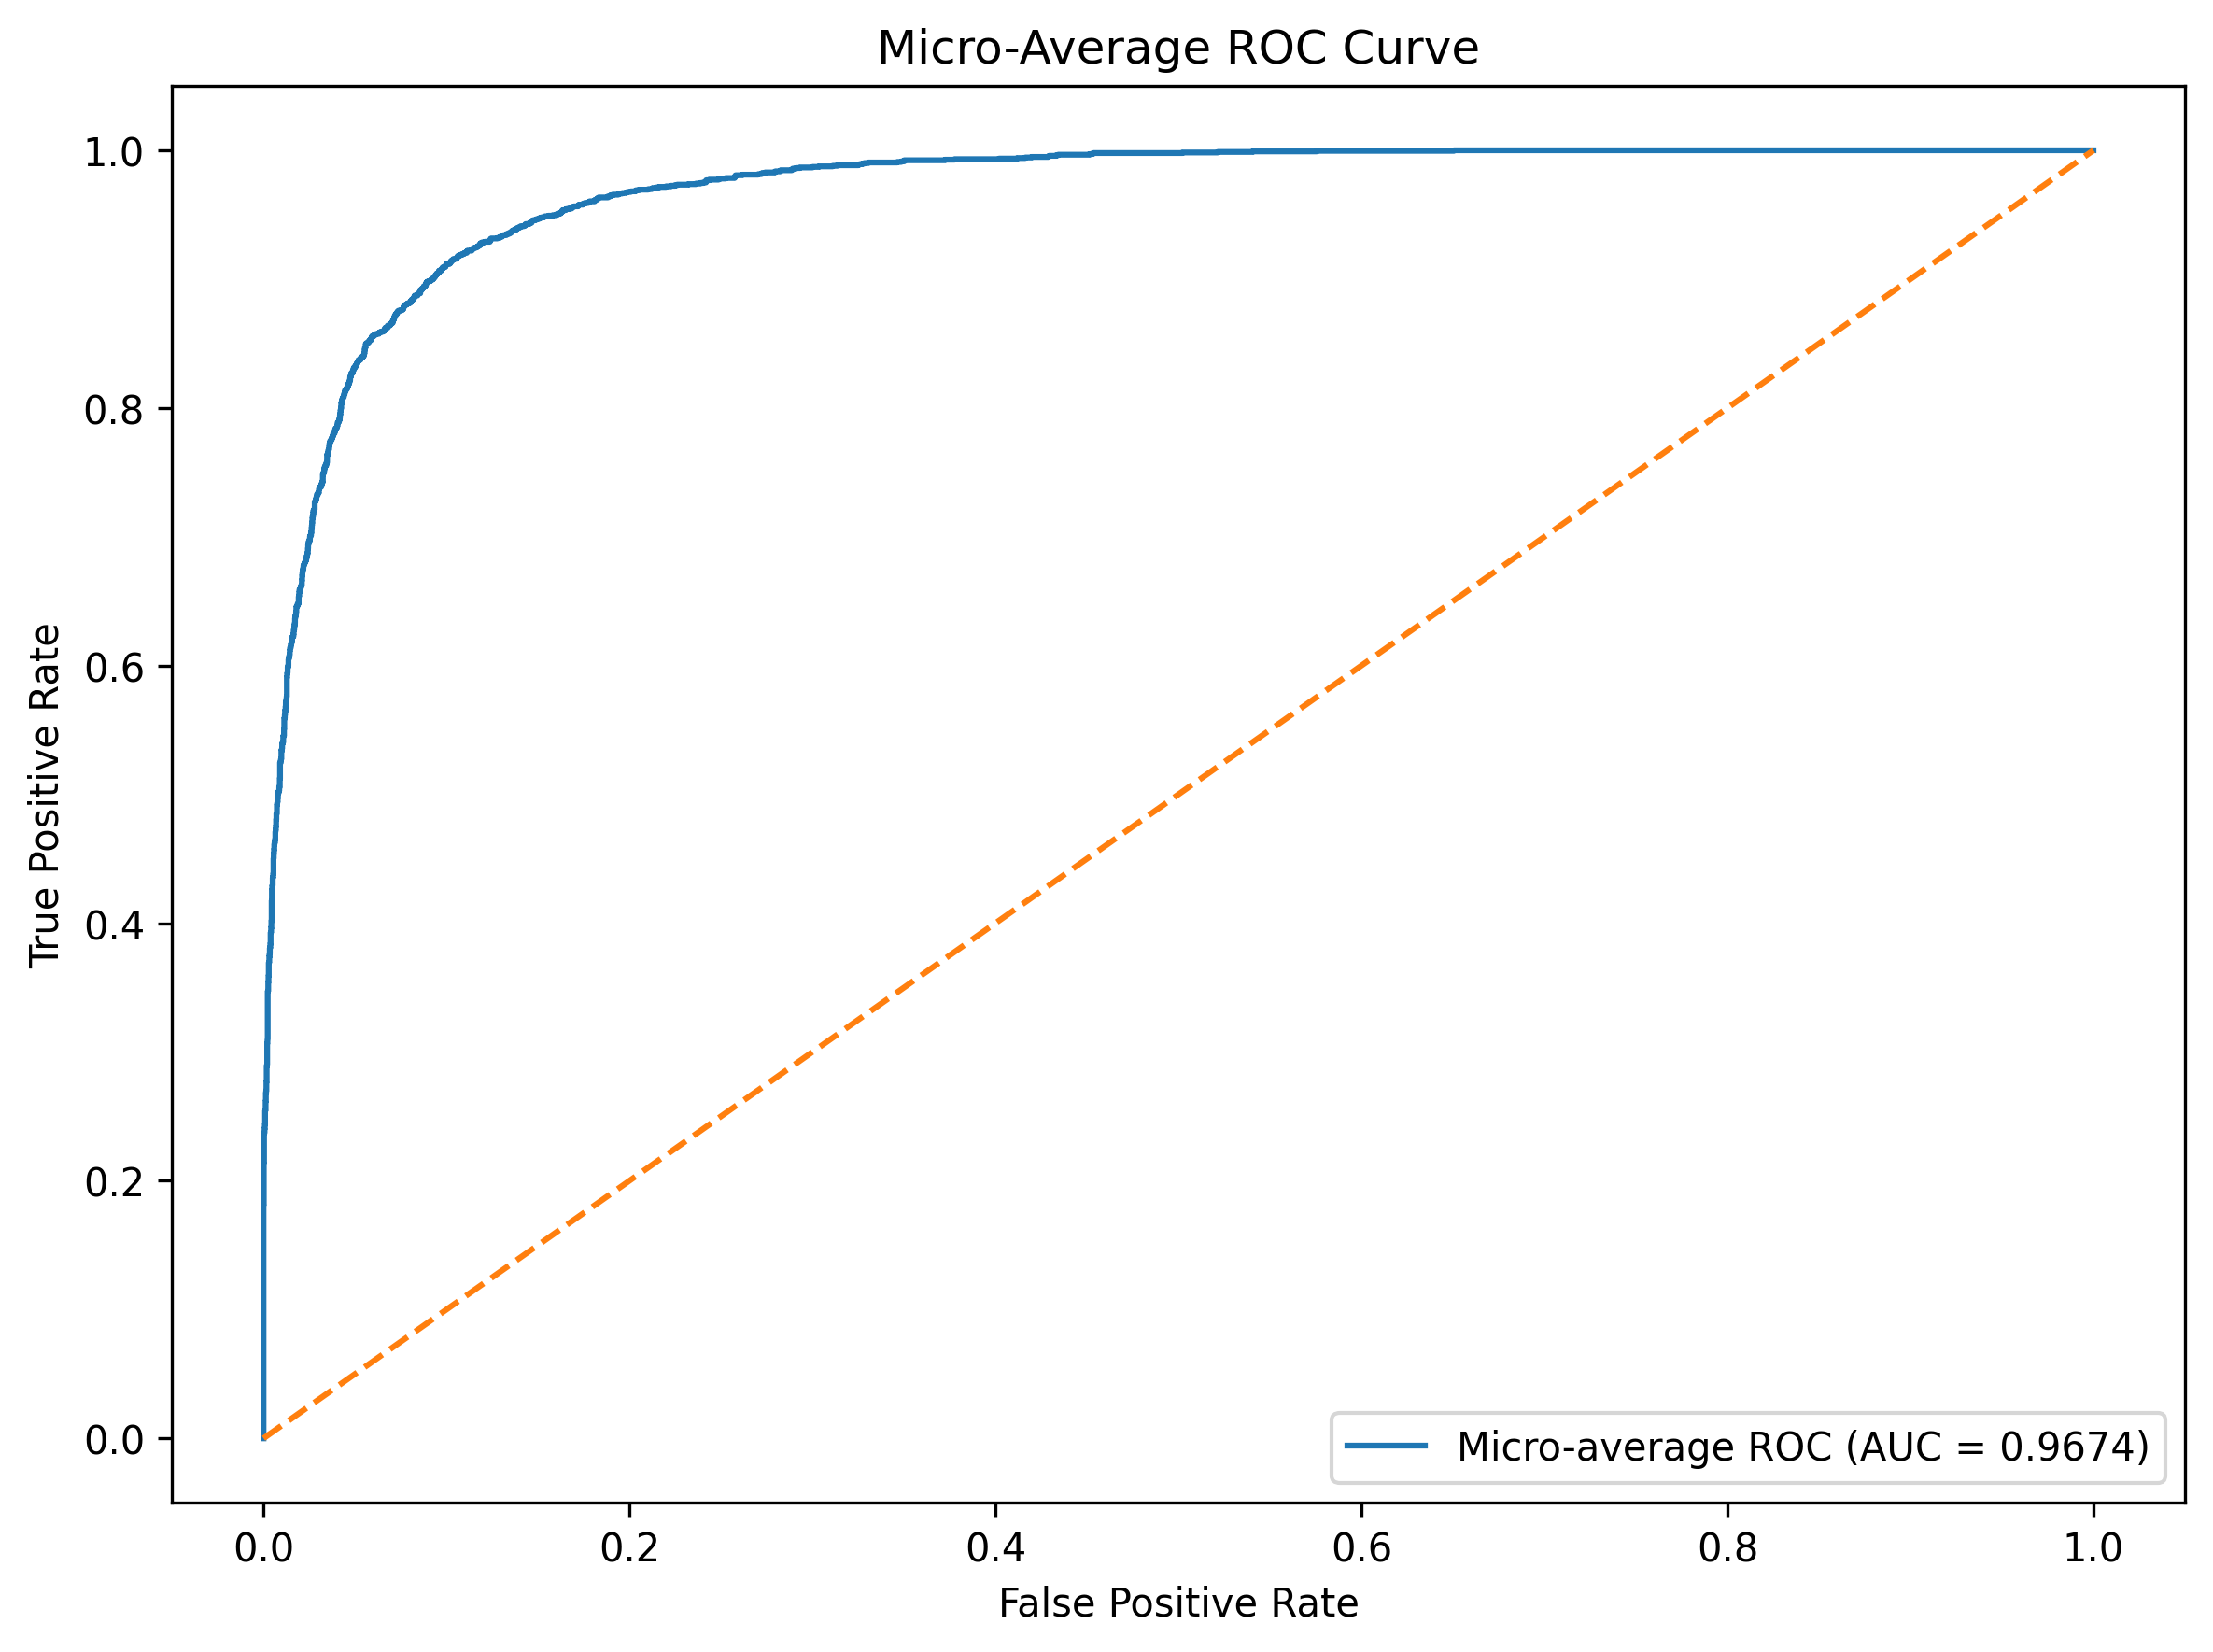

In [32]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

def plot_micro_average_roc(
    y_true,
    y_probs,
    class_names,
    save_path="/kaggle/working/micro_roc.png"
):

    n_classes = len(class_names)

    # Binarize labels
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    # 🔥 Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(
        y_true_bin.ravel(),
        y_probs.ravel()
    )
    auc_micro = auc(fpr_micro, tpr_micro)

    # Plot
    plt.figure(figsize=(8,6), dpi=300)
    plt.plot(
        fpr_micro,
        tpr_micro,
        label=f"Micro-average ROC (AUC = {auc_micro:.4f})"
    )

    # Diagonal
    plt.plot([0,1], [0,1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Micro-Average ROC Curve")
    plt.legend(loc="lower right")

    plt.tight_layout()

    # Save high-res
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved to: {save_path}")

    plt.show()

plot_micro_average_roc(
    y_true,
    y_probs,
    train_dataset.classes
)

Macro-average ROC curve

Saved to: /kaggle/working/macro_roc.png


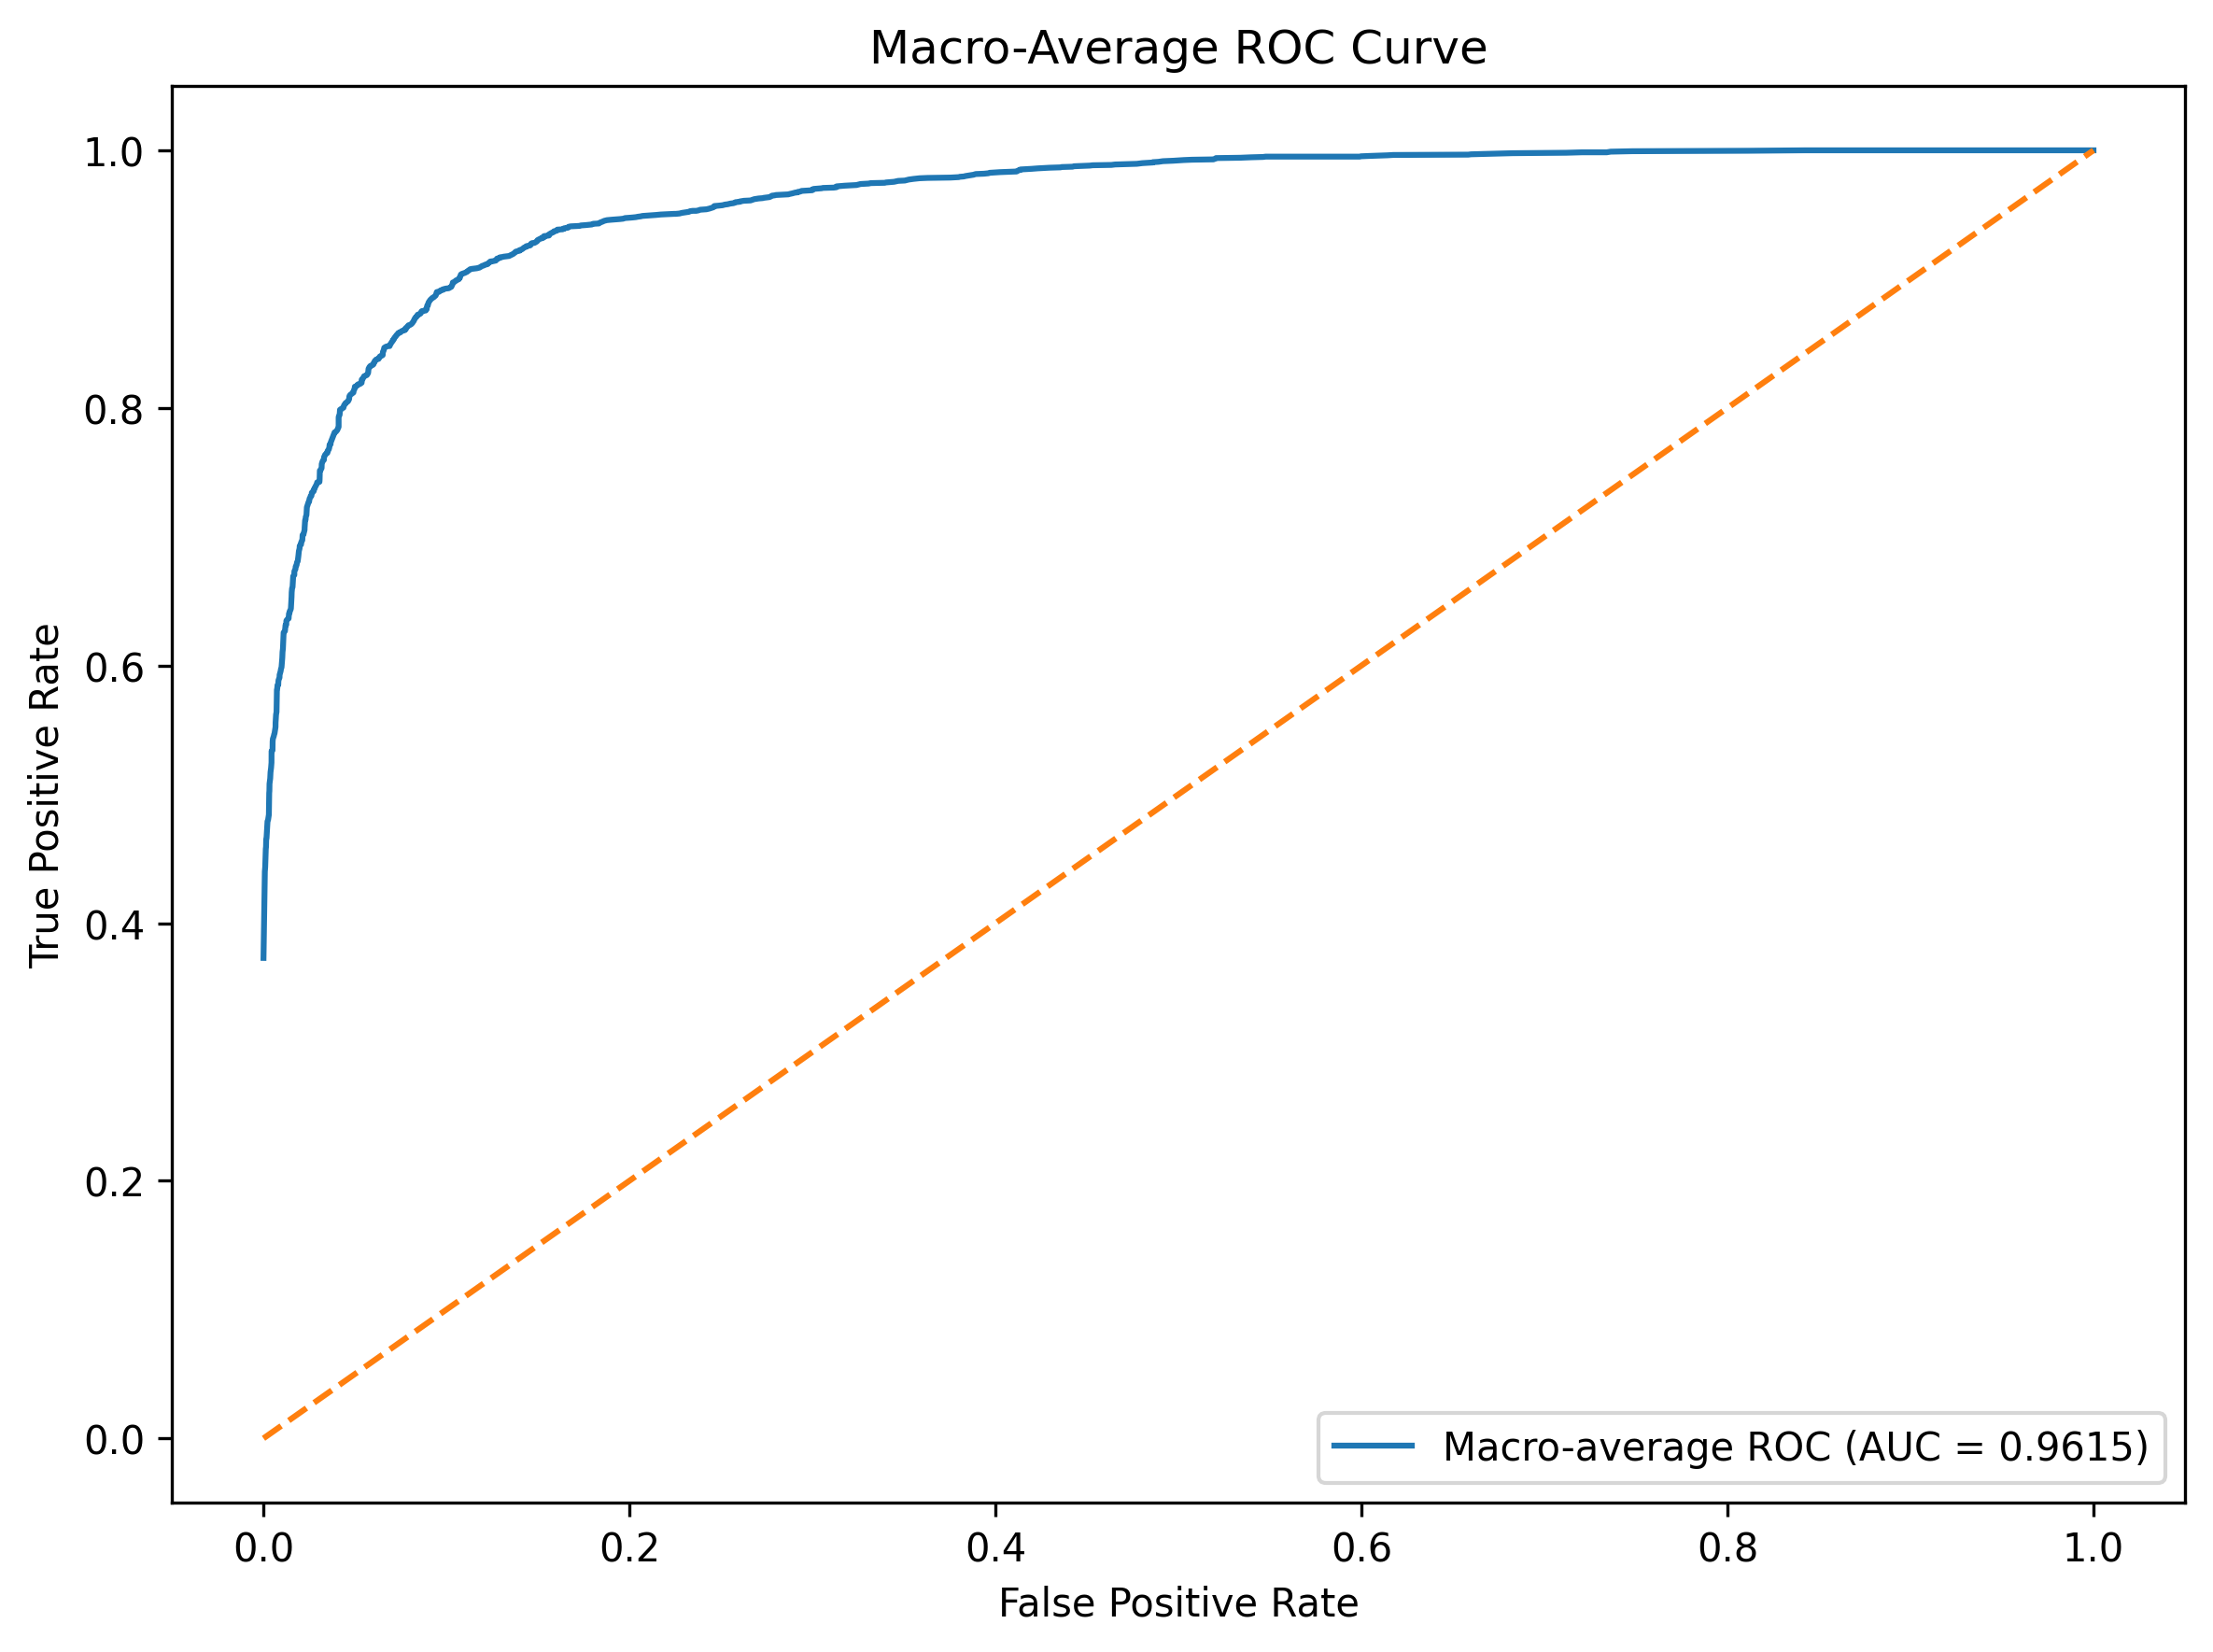

In [33]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

def plot_macro_average_roc(
    y_true,
    y_probs,
    class_names,
    save_path="/kaggle/working/macro_roc.png"
):

    n_classes = len(class_names)

    # Binarize labels
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    # Compute ROC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # 🔥 Aggregate all FPR points
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    # 🔥 Interpolate and average TPR
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes

    macro_auc = auc(all_fpr, mean_tpr)

    # Plot
    plt.figure(figsize=(8,6), dpi=300)

    plt.plot(
        all_fpr,
        mean_tpr,
        label=f"Macro-average ROC (AUC = {macro_auc:.4f})"
    )

    # Diagonal
    plt.plot([0,1], [0,1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Macro-Average ROC Curve")
    plt.legend(loc="lower right")

    plt.tight_layout()

    # Save
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved to: {save_path}")

    plt.show()

plot_macro_average_roc(
    y_true,
    y_probs,
    train_dataset.classes
)

Total trainning time

In [34]:
import time

start_time = time.time()

result = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    EPOCHS
)

end_time = time.time()
training_time = end_time - start_time

if result is None:
    print("Training finished but returned None (early stopping).")
    model = model  # keep current model
else:
    model, train_losses, val_losses, train_accs, val_accs = result

Epoch 1/100
Train Loss: 0.2910, Train Acc: 0.8811
Val Loss: 0.4232, Val Acc: 0.8536
----------------------------------------
Epoch 2/100
Train Loss: 0.2466, Train Acc: 0.9057
Val Loss: 0.4136, Val Acc: 0.8644
----------------------------------------
Epoch 3/100
Train Loss: 0.2498, Train Acc: 0.9009
Val Loss: 0.4113, Val Acc: 0.8614
----------------------------------------
Epoch 4/100
Train Loss: 0.2454, Train Acc: 0.9009
Val Loss: 0.4306, Val Acc: 0.8549
----------------------------------------
Epoch 5/100
Train Loss: 0.2364, Train Acc: 0.9052
Val Loss: 0.4249, Val Acc: 0.8597
----------------------------------------
Epoch 6/100
Train Loss: 0.2282, Train Acc: 0.9063
Val Loss: 0.4353, Val Acc: 0.8579
----------------------------------------
Epoch 7/100
Train Loss: 0.2297, Train Acc: 0.9071
Val Loss: 0.4377, Val Acc: 0.8644
----------------------------------------
Epoch 8/100
Train Loss: 0.2217, Train Acc: 0.9112
Val Loss: 0.4238, Val Acc: 0.8653
----------------------------------------


In [35]:
print(f"\nTotal Training Time: {training_time:.2f} seconds")
print(f"Total Training Time: {training_time/60:.2f} minutes")
print(f"Training Time: {training_time/3600:.2f} hours")


Total Training Time: 1050.29 seconds
Total Training Time: 17.50 minutes
Training Time: 0.29 hours


System info

In [36]:
!pip install psutil

In [37]:
import torch
import psutil
import platform
import os

def print_system_info():

    print("===== SYSTEM INFO =====")

    # OS + Python
    print(f"OS: {platform.system()} {platform.release()}")
    print(f"Python Version: {platform.python_version()}")

    # CPU
    print(f"\nCPU: {platform.processor()}")
    print(f"CPU Cores: {psutil.cpu_count(logical=True)}")

    # RAM
    ram = psutil.virtual_memory()
    print(f"\nTotal RAM: {ram.total / (1024**3):.2f} GB")
    print(f"Available RAM: {ram.available / (1024**3):.2f} GB")
    print(f"Used RAM: {ram.used / (1024**3):.2f} GB")

    # Disk (ROM)
    disk = psutil.disk_usage('/')
    print(f"\nTotal Disk: {disk.total / (1024**3):.2f} GB")
    print(f"Used Disk: {disk.used / (1024**3):.2f} GB")
    print(f"Free Disk: {disk.free / (1024**3):.2f} GB")

    # GPU
    print("\n===== GPU INFO =====")
    if torch.cuda.is_available():
        print(f"GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"GPU Count: {torch.cuda.device_count()}")

        props = torch.cuda.get_device_properties(0)
        print(f"Total GPU Memory: {props.total_memory / (1024**3):.2f} GB")

        print(f"Allocated GPU Memory: {torch.cuda.memory_allocated(0) / (1024**3):.2f} GB")
        print(f"Reserved GPU Memory: {torch.cuda.memory_reserved(0) / (1024**3):.2f} GB")
    else:
        print("No GPU available")

print_system_info()

===== SYSTEM INFO =====
OS: Linux 6.6.113+
Python Version: 3.12.12

CPU: x86_64
CPU Cores: 4

Total RAM: 31.35 GB
Available RAM: 29.08 GB
Used RAM: 1.82 GB

Total Disk: 8062.39 GB
Used Disk: 6842.12 GB
Free Disk: 1220.25 GB

===== GPU INFO =====
GPU Name: Tesla T4
GPU Count: 2
Total GPU Memory: 14.56 GB
Allocated GPU Memory: 0.84 GB
Reserved GPU Memory: 1.12 GB


GPU Memory info

In [38]:
if torch.cuda.is_available():
    print(f"GPU Memory Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"GPU Memory Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

GPU Memory Allocated: 859.05 MB
GPU Memory Reserved: 1144.00 MB


GPU Used

In [39]:
torch.cuda.reset_peak_memory_stats()

# run training...

peak_mem = torch.cuda.max_memory_allocated() / (1024**3)
print(f"Peak GPU Memory Used: {peak_mem:.2f} GB")

Peak GPU Memory Used: 0.84 GB


CPU Usage

In [40]:
print(f"CPU Usage: {psutil.cpu_percent()}%")

CPU Usage: 44.6%


In [41]:
torch.save(model.state_dict(), "/kaggle/working/best_model.pth")

In [42]:
checkpoint = torch.load("/kaggle/working/best_model.pth")
print(list(checkpoint.keys())[:10])

['features.0.weight', 'features.0.bias', 'features.3.weight', 'features.3.bias', 'features.6.weight', 'features.6.bias', 'features.8.weight', 'features.8.bias', 'features.10.weight', 'features.10.bias']


Save & Load

In [43]:
torch.save(model.state_dict(), "/kaggle/working/alexnet_best.pth")

In [44]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = len(train_dataset.classes)

# Recreate AlexNet
model = models.alexnet(weights=None)

# Recreate the SAME classifier you used in training
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, len(train_dataset.classes))

# Load saved weights
model.load_state_dict(torch.load("/kaggle/working/alexnet_best.pth"))

model = model.to(device)
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [45]:
torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "val_acc": val_acc
}, "/kaggle/working/alexnet_checkpoint.pth")

In [46]:
checkpoint = torch.load("/kaggle/working/alexnet_checkpoint.pth")

model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

In [47]:
torch.save(model.state_dict(), "alexnet_best.pth")

In [48]:
model = models.alexnet(weights=None)
model.classifier[6] = nn.Linear(num_features, num_classes)
model.load_state_dict(torch.load("alexnet_best.pth"))
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [49]:
import os

print(os.path.exists("/kaggle/working/alexnet_best.pth"))

True


In [50]:
import os

print(os.listdir("/kaggle/working"))

['confusion_matrix.png', '__notebook__.ipynb', 'alexnet_best.pth', 'macro_roc.png', 'best_model.pth', 'normalized_confusion_matrix.png', 'roc_curve.png', 'per_class_accuracy.png', 'alexnet_checkpoint.pth', 'micro_roc.png']


In [51]:
os.path.getsize("/kaggle/working/alexnet_best.pth")

228087457

In [52]:
state_dict = torch.load("/kaggle/working/alexnet_best.pth")
print(type(state_dict))

<class 'collections.OrderedDict'>


In [53]:
import torch
from torchvision import models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)

model = models.alexnet(weights=None)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

model.load_state_dict(torch.load("/kaggle/working/alexnet_best.pth"))

# ⭐ IMPORTANT FIX
model = model.to(device)
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [54]:
import os
from PIL import Image

base_path = "/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split/test/No Sunburn/normal_7da908e123b9da3711df_jpg.rf.1ff15d847cca77a7694aeb24428a7ce6.jpg"

# Find first image
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith((".jpg", ".png", ".jpeg")):
            img_path = os.path.join(root, file)
            break
    if 'img_path' in locals():
        break

print("Using image:", img_path)

image = Image.open(img_path).convert("RGB")

Using image: /kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split/train/Second Degree Burn Partial of Intermediate Thickness/augmented_rotate_45_img1215_jpg.rf.2015ac8ceb7ad728b0fcd09e9f5c31e5.jpg


In [55]:
import torch
from PIL import Image
import torchvision.transforms as transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform (VERY IMPORTANT)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),   # 🔥 THIS fixes your error
])

# Load image
img_path = "/kaggle/input/datasets/samiasayedsumona/skinburndataset/dataset_split/test/No Sunburn/normal_7da908e123b9da3711df_jpg.rf.1ff15d847cca77a7694aeb24428a7ce6.jpg"
image = Image.open(img_path).convert("RGB")

# Apply transform
image = transform(image)        # PIL → Tensor
image = image.unsqueeze(0)      # Add batch dimension
image = image.to(device)

print(type(image))              # should be torch.Tensor
print(image.shape)              # [1, 3, 224, 224]

<class 'torch.Tensor'>
torch.Size([1, 3, 224, 224])


In [56]:
starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)

model.eval()

starter.record()

with torch.no_grad():
    output = model(image)

ender.record()

torch.cuda.synchronize()

inference_time = starter.elapsed_time(ender)  # ms

_, pred = torch.max(output, 1)
predicted_class = class_names[pred.item()]

print(f"Prediction: {predicted_class}")
print(f"Inference Time: {inference_time:.4f} ms")

Prediction: No Sunburn
Inference Time: 2.6857 ms


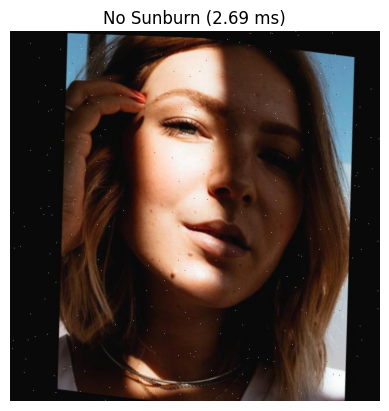

In [57]:
import matplotlib.pyplot as plt

plt.imshow(Image.open(img_path))
plt.title(f"{predicted_class} ({inference_time:.2f} ms)")
plt.axis("off")
plt.show()